In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
RNG = np.random.default_rng(42)

In [8]:
# Ordens naturais dos atributos (importante para análise ordinal)
ATTR_ORDER = {
    "buying":   ["low", "med", "high", "vhigh"],
    "maint":    ["low", "med", "high", "vhigh"],
    "doors":    ["2", "3", "4", "5more"],
    "persons":  ["2", "4", "more"],
    "lug_boot": ["small", "med", "big"],
    "safety":   ["low", "med", "high"],
}
CLASS_ORDER = ["unacc", "acc", "good", "vgood"]
CLASS_PALETTE = {
    "unacc": "#d6604d", "acc": "#f4a582",
    "good":  "#92c5de", "vgood": "#2166ac",
}

In [9]:
COLS = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df = pd.read_csv("data/car.data", header=None, names=COLS)

# Tipar como categórico ordenado
for c, order in ATTR_ORDER.items():
    df[c] = pd.Categorical(df[c], categories=order, ordered=True)
df["class"] = pd.Categorical(df["class"], categories=CLASS_ORDER, ordered=True)

print("Shape:", df.shape)
df.head()

Shape: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [10]:
print(df.dtypes)
print()
print("Valores faltantes por coluna:", df.isna().sum().to_dict())
print("Linhas duplicadas           :", df.duplicated().sum())

buying      category
maint       category
doors       category
persons     category
lug_boot    category
safety      category
class       category
dtype: object

Valores faltantes por coluna: {'buying': 0, 'maint': 0, 'doors': 0, 'persons': 0, 'lug_boot': 0, 'safety': 0, 'class': 0}
Linhas duplicadas           : 0


In [11]:
class_counts = df["class"].value_counts().reindex(CLASS_ORDER)
class_pct = (class_counts / len(df) * 100).round(2)
pd.DataFrame({"n": class_counts, "%": class_pct})

,n,%
class,,
unacc,1210,70.02
acc,384,22.22
good,69,3.99
vgood,65,3.76


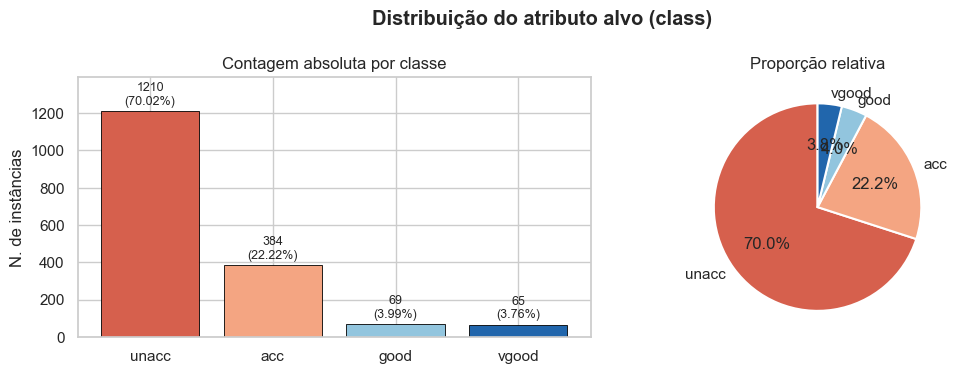

Razão majoritária/minoritária: 18.62x 


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(class_counts.index, class_counts.values,
            color=[CLASS_PALETTE[c] for c in class_counts.index],
            edgecolor="black", linewidth=0.6)
for i, (c, v) in enumerate(class_counts.items()):
    axes[0].text(i, v + 20, f"{v}\n({class_pct[c]}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("Contagem absoluta por classe")
axes[0].set_ylabel("N. de instâncias")
axes[0].set_ylim(0, class_counts.max()*1.15)

axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=[CLASS_PALETTE[c] for c in class_counts.index],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[1].set_title("Proporção relativa")
plt.suptitle("Distribuição do atributo alvo (class)", fontweight="bold")
plt.tight_layout(); plt.show()

imb = class_counts.max()/class_counts.min()
print(f"Razão majoritária/minoritária: {imb:.2f}x ")

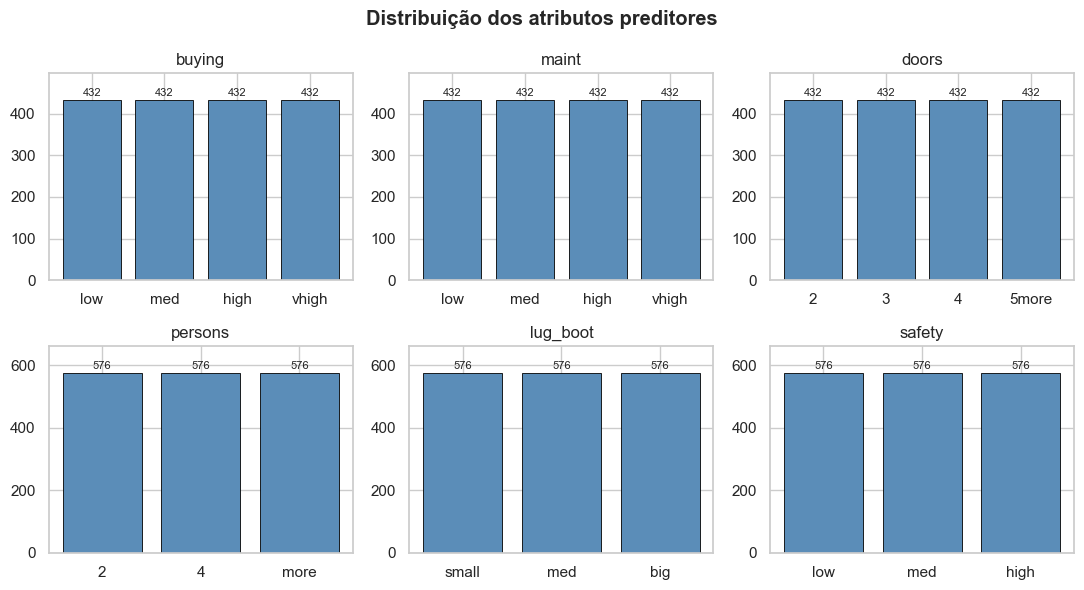

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, attr in zip(axes.flat, ATTR_ORDER):
    counts = df[attr].value_counts().reindex(ATTR_ORDER[attr])
    ax.bar(counts.index.astype(str), counts.values,
           color="#5B8DB8", edgecolor="black", linewidth=0.6)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha="center", va="bottom", fontsize=8)
    ax.set_title(attr)
    ax.set_ylim(0, counts.max()*1.15)
plt.suptitle("Distribuição dos atributos preditores", fontweight="bold")
plt.tight_layout(); plt.show()

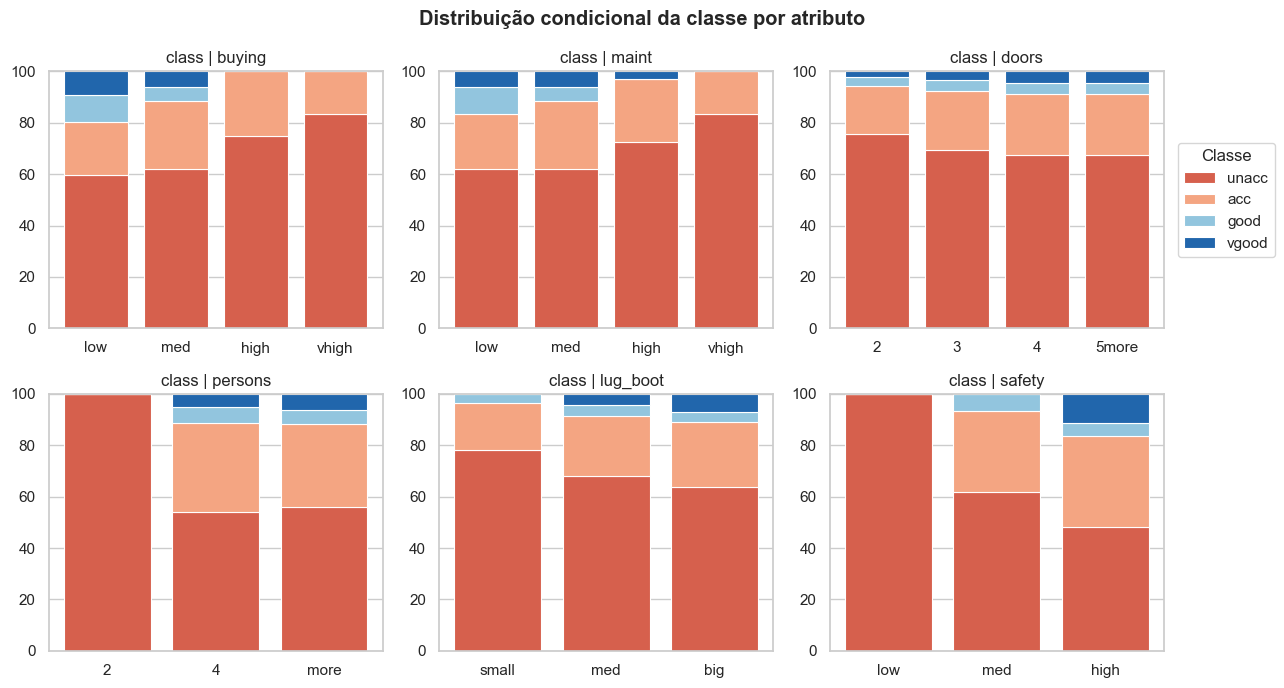

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, attr in zip(axes.flat, ATTR_ORDER):
    ct = pd.crosstab(df[attr], df["class"], normalize="index")\
            .reindex(ATTR_ORDER[attr])[CLASS_ORDER] * 100
    bottom = np.zeros(len(ct))
    for cls in CLASS_ORDER:
        ax.bar(ct.index.astype(str), ct[cls].values, bottom=bottom,
               color=CLASS_PALETTE[cls], label=cls,
               edgecolor="white", linewidth=0.8)
        bottom += ct[cls].values
    ax.set_title(f"class | {attr}")
    ax.set_ylim(0, 100)
axes[0,2].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Classe")
plt.suptitle("Distribuição condicional da classe por atributo", fontweight="bold")
plt.tight_layout(); plt.show()

In [15]:
for attr in ATTR_ORDER:
    print(f"\n{attr} × class:")
    print(pd.crosstab(df[attr], df["class"]).reindex(ATTR_ORDER[attr])[CLASS_ORDER])


buying × class:
class   unacc  acc  good  vgood
buying                         
low       258   89    46     39
med       268  115    23     26
high      324  108     0      0
vhigh     360   72     0      0

maint × class:
class  unacc  acc  good  vgood
maint                         
low      268   92    46     26
med      268  115    23     26
high     314  105     0     13
vhigh    360   72     0      0

doors × class:
class  unacc  acc  good  vgood
doors                         
2        326   81    15     10
3        300   99    18     15
4        292  102    18     20
5more    292  102    18     20

persons × class:
class    unacc  acc  good  vgood
persons                         
2          576    0     0      0
4          312  198    36     30
more       322  186    33     35

lug_boot × class:
class     unacc  acc  good  vgood
lug_boot                         
small       450  105    21      0
med         392  135    24     25
big         368  144    24     40

safety × class